In [ ]:
%pip install pandas numpy joblib matplotlib mplfinance scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached mplfinance-0.12.10b0-py3-none-any.whl.metadata (19 kB)
Using cached mplfinance-0.12.10b0-py3-none-any.whl (75 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\tromb\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import os, math
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import mplfinance as mpf
from datetime import timedelta

# load models
lgb_model = joblib.load("models/lgb_model.pkl")
xgb_model = joblib.load("models/xgb_model.pkl")
gb_model  = joblib.load("models/gb_model.pkl")
scaler = joblib.load("models/scaler.pkl")
FEATURES = joblib.load("models/features_list.pkl")

print("Loaded models and scaler. Features:", FEATURES)


Loaded models and scaler. Features: ['ret1', 'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_5', 'ret_lag_10', 'roll_std_10', 'vol_lag_1', 'reddit_count_60m', 'reddit_sent_60m', 'news_count_60m', 'news_sent_60m']


In [2]:
df = pd.read_csv("data/raw.csv", parse_dates=['timestamp'])
df = df.sort_values(['symbol','timestamp']).reset_index(drop=True)


coins = sorted(df['symbol'].unique())
print("Available coins:", coins)
coin = coins[1]  #changeable
print("Using coin:", coin)

df_coin = df[df['symbol']==coin].sort_values('timestamp').reset_index(drop=True)

Available coins: ['BTC/USDT', 'ETH/USDT', 'SOL/USDT']
Using coin: ETH/USDT


In [3]:
def build_latest_features(df_coin):
    g = df_coin.copy().sort_values('timestamp').reset_index(drop=True)
    g['ret1'] = g['close'].pct_change().fillna(0)
    for l in [1,2,3,5,10]:
        g[f'ret_lag_{l}'] = g['ret1'].shift(l).fillna(0)
    g['roll_std_10'] = g['ret1'].rolling(window=10, min_periods=1).std().fillna(0)
    g['vol_lag_1'] = g['volume'].pct_change().fillna(0)
    last = g.iloc[-1]
    feat = [ last.get(f,0.0) for f in FEATURES ]
    return np.array(feat).reshape(1,-1), g

X_latest_raw, g = build_latest_features(df_coin)
X_latest = scaler.transform(X_latest_raw)

In [4]:
H = 9  
last_price = float(g['close'].iloc[-1])
timestamps = [g['timestamp'].iloc[-1] + timedelta(minutes=i+1) for i in range(H)]

def simulate_path(model, X_seed, last_price, H=9, stochastic=True):
    """
    Autoregressive: predict next-minute return r_t, update price p_{t+1}=p_t*(1+r_t)
    For next step, we update some inputs (simple approach: shift ret_lag values).
    Keep it concise but realistic: add small noise if stochastic True.
    """
    path = []
    cur_price = last_price
    X = X_seed.copy()
    for i in range(H):
        r_pred = float(model.predict(X)[0])
        if stochastic:
            noise = np.random.normal(0, abs(r_pred)*0.3 + 1e-6)
            r_pred = r_pred + noise
        cur_price = cur_price * (1 + r_pred)
        path.append(cur_price)
        feature_names = FEATURES
        new_vals = []
        # ret1
        new_vals.append(r_pred)
        # ret_lag_1, ret_lag_2, ...
        for lag in [1,2,3,5,10]:
            col = f'ret_lag_{lag}'
            if col in feature_names:
                prev_val = X[0, feature_names.index(col)] if col in feature_names else 0.0
                new_vals.append(prev_val)
        extras = []
        for ex in ['roll_std_10','vol_lag_1','reddit_count_60m','reddit_sent_60m','news_count_60m','news_sent_60m']:
            if ex in feature_names:
                extras.append(X[0, feature_names.index(ex)])
        X_next = X.copy()
        for idx,name in enumerate(feature_names):
            if name == 'ret1':
                X_next[0, idx] = new_vals[0]
            elif name.startswith('ret_lag_'):
                if name == 'ret_lag_1':
                    X_next[0, idx] = new_vals[0]
                else:
                    X_next[0, idx] = X[0, idx]
            else:
                X_next[0, idx] = X[0, idx]
        X = X_next
    return path

# simulate for each model
np.random.seed(42)
path_lgb = simulate_path(lgb_model, X_latest.copy(), last_price, H=H)
path_xgb = simulate_path(xgb_model, X_latest.copy(), last_price, H=H)
path_gb  = simulate_path(gb_model,  X_latest.copy(), last_price, H=H)

C:\Users\tromb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\tromb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\tromb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\tromb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packag

In [5]:
N = 90
recent = df_coin.tail(N).copy()
recent = recent.set_index(pd.DatetimeIndex(recent['timestamp']))

if not set(['open','high','low','close']).issubset(recent.columns):
    recent['open'] = recent['close'].shift(1).fillna(recent['close'])
    recent['high'] = recent[['open','close']].max(axis=1)*(1+0.0005)
    recent['low']  = recent[['open','close']].min(axis=1)*(1-0.0005)
if 'volume' not in recent.columns:
    recent['volume'] = 1.0

mpf_df = recent[['open','high','low','close','volume']].copy()

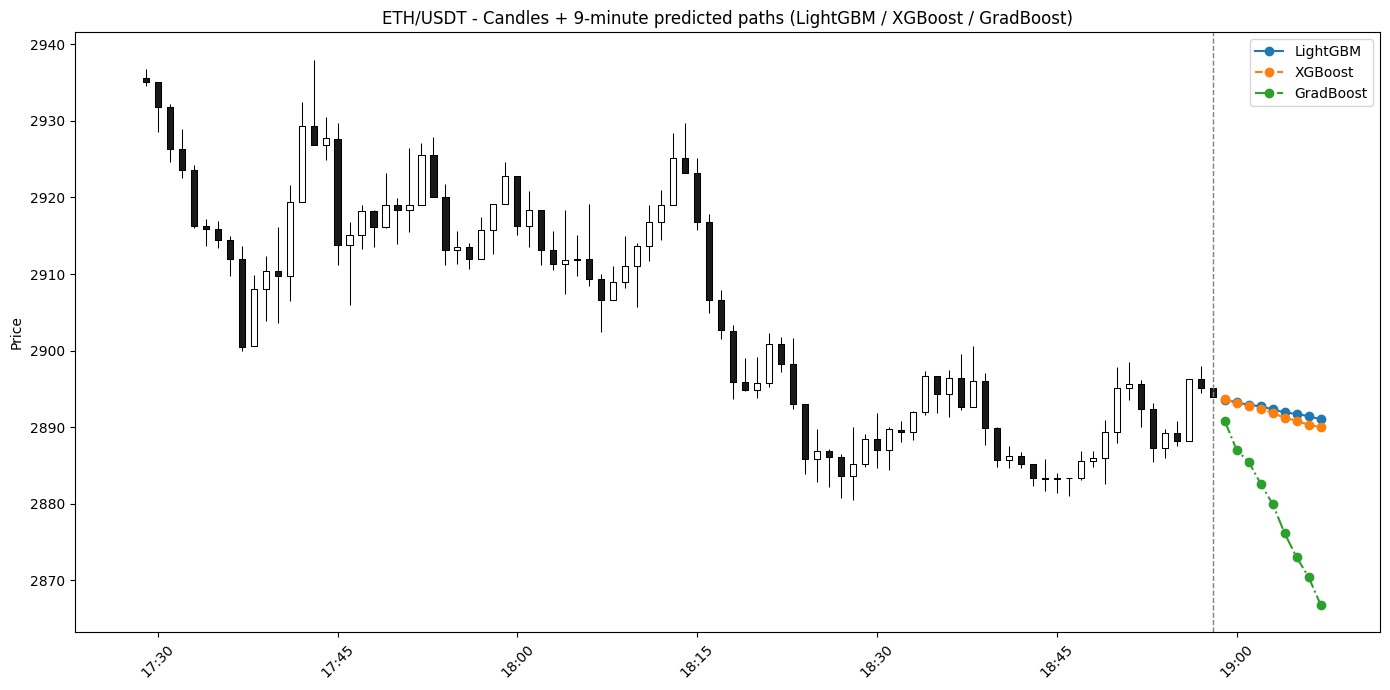

In [6]:
fig, ax = plt.subplots(figsize=(14,7))
mpf.plot(mpf_df, type='candle', ax=ax, volume=False, show_nontrading=True)

future_times = timestamps
ax.plot(future_times, path_lgb, marker='o', linestyle='-', color='tab:blue', label='LightGBM')
ax.plot(future_times, path_xgb, marker='o', linestyle='--', color='tab:orange', label='XGBoost')
ax.plot(future_times, path_gb,  marker='o', linestyle='-.', color='tab:green', label='GradBoost')

ax.axvline(mpf_df.index[-1], color='gray', linestyle='--', linewidth=1)
ax.legend()
ax.set_title(f"{coin} - Candles + {H}-minute predicted paths (LightGBM / XGBoost / GradBoost)")
plt.tight_layout()
plt.show()

In [7]:
pred_table = pd.DataFrame({
    'timestamp': [t.strftime("%Y-%m-%d %H:%M") for t in future_times],
    'LightGBM': np.round(path_lgb,4),
    'XGBoost': np.round(path_xgb,4),
    'GradBoost': np.round(path_gb,4)
})
print(pred_table)

          timestamp   LightGBM    XGBoost  GradBoost
0  2025-11-19 18:59  2893.6133  2893.6186  2890.8275
1  2025-11-19 19:00  2893.2235  2893.1914  2886.9826
2  2025-11-19 19:01  2892.9243  2892.7641  2885.4772
3  2025-11-19 19:02  2892.7257  2892.4182  2882.6013
4  2025-11-19 19:03  2892.3251  2891.8245  2879.9659
5  2025-11-19 19:04  2891.9245  2891.2526  2876.1253
6  2025-11-19 19:05  2891.7324  2890.8144  2873.0013
7  2025-11-19 19:06  2891.4471  2890.3245  2870.4097
8  2025-11-19 19:07  2891.0196  2889.9873  2866.8026
